# AML Fraud Detection Machine Learning Pipeline

This notebook implements a complete, reusable machine learning pipeline for Anti-Money Laundering (AML) fraud detection. The goal is to build a robust system that downcasts data to optimize memory, engineers advanced AML-specific features, handles class imbalance, trains and tunes multiple models (Logistic Regression, Random Forest, XGBoost), and provides model explainability using SHAP. All outputs are saved and a reusable inference function is provided.

## Objectives:
1. **Dataset Inspection**: Load datasets, detect targets automatically, check shapes, data types, missing values, and duplicates.
2. **Exploratory Data Analysis (EDA)**: Visualizations of target imbalance, amounts, payment formats, customer patterns, and correlations.
3. **Data Cleaning**: Remove duplicates, handle timestamps, and downcast numerical types to optimize RAM usage.
4. **Feature Engineering**: High-performance O(N) single-pass extraction of rolling averages, transaction counts over hours/days/weeks, time since previous transaction, and currency/amount mismatches.
5. **Imbalance Handling**: Apply class weighting and scale_pos_weight to avoid synthetic noise (like SMOTE) and speed up training.
6. **Model Training**: Stratified splits, randomized grid search for hyperparameter tuning, and fitting Logistic Regression, Random Forest, and XGBoost.
7. **Evaluation**: Compute Accuracy, Precision, Recall, F1-Score, ROC-AUC, PR-AUC, and select the best balanced model for fraud detection.
8. **Explainability**: Generate global and local SHAP explanation plots and create a reusable prediction explainer.
9. **Save Artifacts**: Export all models, preprocessing pipelines, and encoders.
10. **Reusable Inference**: Create a fast prediction function supporting model selection.


## Setup & Imports

Import all necessary libraries for data processing, visualization, modeling, and explainability.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import time
import joblib
import warnings
from collections import defaultdict, deque
import bisect

from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import FunctionTransformer
from xgboost import XGBClassifier
import shap

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')


## 1. Data Loading

Load the two CSV datasets (`mixed_aml_dataset.csv` and `mixed_aml_dataset_medium.csv`) and concatenate them into a single DataFrame.


In [2]:
csv1_path = 'mixed_aml_dataset.csv'
csv2_path = 'mixed_aml_dataset_medium.csv'

print('Loading datasets...')
df1 = pd.read_csv(csv1_path)
df2 = pd.read_csv(csv2_path)
df = pd.concat([df1, df2], ignore_index=True)
print(f'Combined Dataset Shape: {df.shape}')


Loading datasets...


Combined Dataset Shape: (360078, 18)


## 2. Initial Inspection & Target Detection

Display column names, infer types, check missing values, duplicate records, and automatically detect the target label. If target label is not explicitly found, fallback to default configurations.


In [3]:
print('--- Column Names and Data Types ---')
print(df.info())

print('\n--- Missing Values Per Column ---')
print(df.isnull().sum())

print(f'\nDuplicate rows detected: {df.duplicated().sum()}')

# Target detection
target_col = None
for col in ['Is_Laundering', 'is_laundering', 'Is_Fraud', 'is_fraud']:
    if col in df.columns:
        target_col = col
        break

if target_col:
    print(f'\nAutomatically detected target column: "{target_col}"')
    fraud_counts = df[target_col].value_counts()
    print(f'Class Distribution:\n{fraud_counts}')
    print(f'Fraud Ratio: {fraud_counts.get(1, 0) / len(df) * 100:.2f}%')
else:
    raise ValueError('Could not automatically detect the target label. Please specify target_col explicitly.')


--- Column Names and Data Types ---


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360078 entries, 0 to 360077
Data columns (total 18 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Timestamp             360078 non-null  object 
 1   From Bank             360078 non-null  int64  
 2   Account               360078 non-null  object 
 3   To Bank               360078 non-null  int64  
 4   Account.1             360078 non-null  object 
 5   Amount Received       360078 non-null  float64
 6   Receiving Currency    360078 non-null  object 
 7   Amount Paid           360078 non-null  float64
 8   Payment Currency      360078 non-null  object 
 9   Payment Format        360078 non-null  object 
 10  Is_Laundering         360078 non-null  int64  
 11  Bank Name_sender      360078 non-null  object 
 12  Entity ID_sender      360078 non-null  object 
 13  Entity Name_sender    360078 non-null  object 
 14  Bank Name_receiver    360078 non-null  object 
 15  

Timestamp               0
From Bank               0
Account                 0
To Bank                 0
Account.1               0
Amount Received         0
Receiving Currency      0
Amount Paid             0
Payment Currency        0
Payment Format          0
Is_Laundering           0
Bank Name_sender        0
Entity ID_sender        0
Entity Name_sender      0
Bank Name_receiver      0
Entity ID_receiver      0
Entity Name_receiver    0
Source_Set              0
dtype: int64



Duplicate rows detected: 0

Automatically detected target column: "Is_Laundering"
Class Distribution:
Is_Laundering
0    300065
1     60013
Name: count, dtype: int64
Fraud Ratio: 16.67%


## 3. Exploratory Data Analysis (EDA)

Visualize target balance, transaction amount distributions, payment formats, active entities, temporal patterns, and feature correlations.

### Key Visualizations:
1. **Class Distribution**: Shows target imbalance (approx 16.7% fraud ratio). Models must address this through weights rather than simple accuracy metrics.
2. **Amount Paid (Log Scale)**: Visualizes the transaction value distribution. Heavy right-skewed amounts are normal, but anomalies appear at higher scales.
3. **Payment Formats**: Displays channels. Cheques, ACH, and Credit Cards are dominant, while cash and wires are fewer but potentially higher-risk.
4. **Top Active Senders**: Highlights entities with the highest transactional volumes. In AML, massive frequency for a single sender indicates shell company transactions.
5. **Hour of Day pattern**: Transactions occur across all hours, with some dips at early mornings. Fraudulent activities often deviate from normal patterns.
6. **Missing Values**: Shows zero missing values, confirming the data is complete.
7. **Correlation Heatmap**: Initial features display low correlations except between amounts received and paid (which are almost identical).


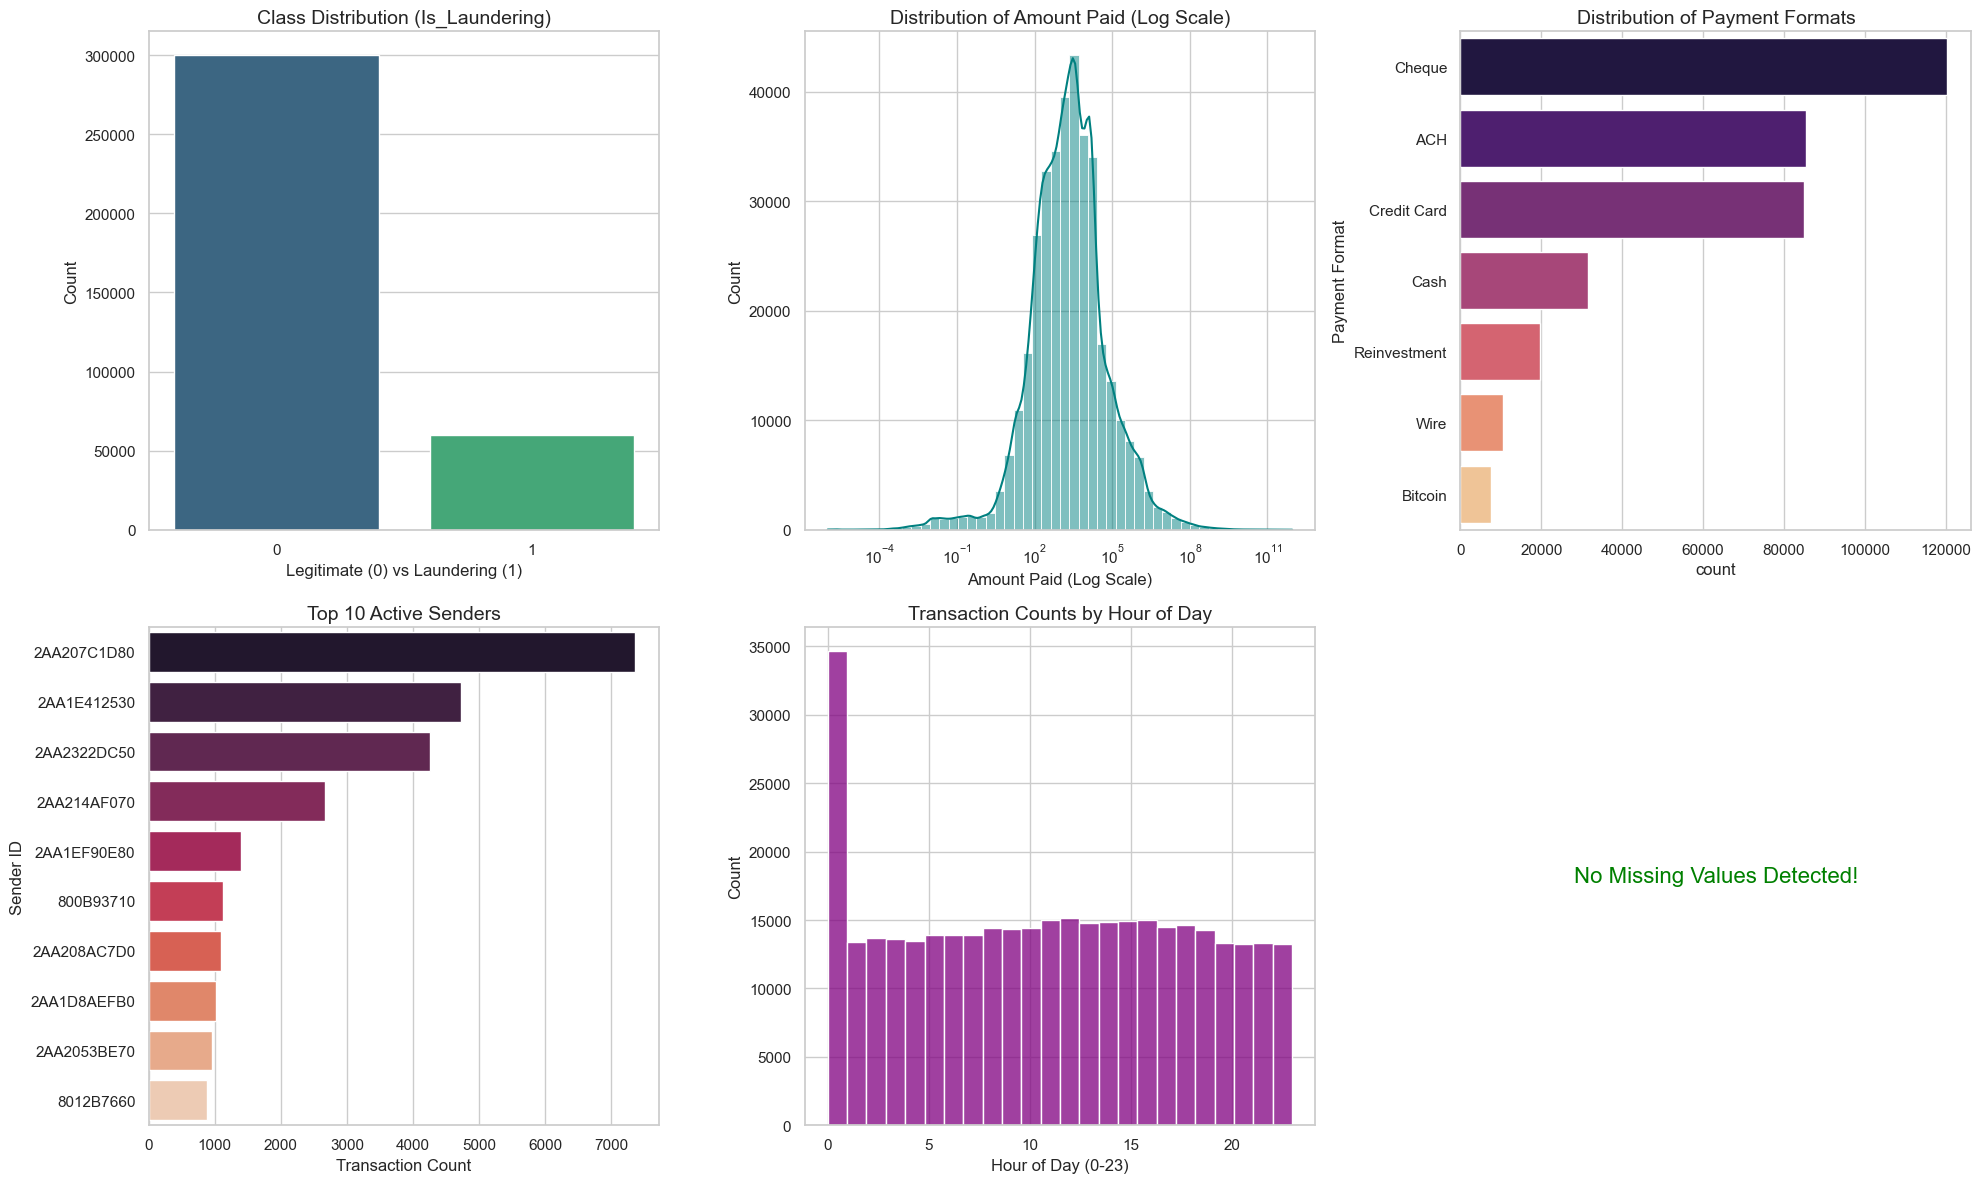

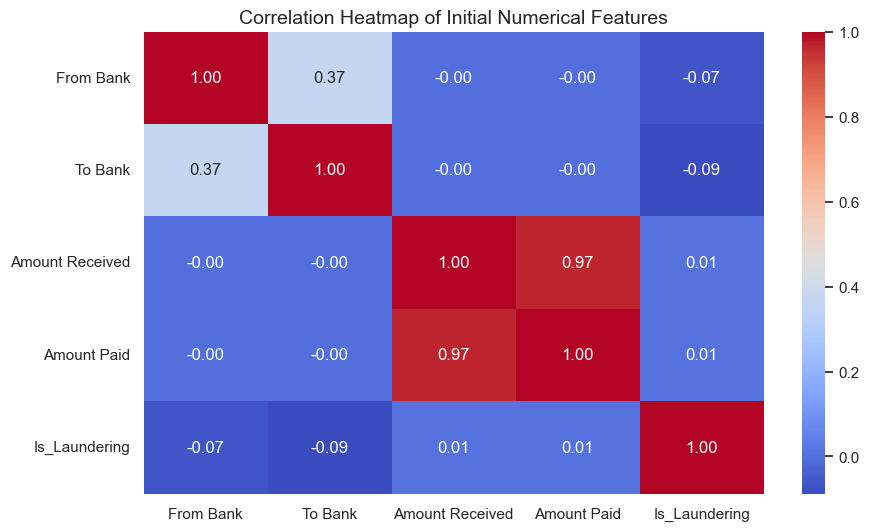

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. Class Distribution
sns.countplot(ax=axes[0, 0], x=target_col, data=df, palette='viridis')
axes[0, 0].set_title('Class Distribution (Is_Laundering)', fontsize=14)
axes[0, 0].set_xlabel('Legitimate (0) vs Laundering (1)')
axes[0, 0].set_ylabel('Count')

# 2. Transaction Amount Distribution
sns.histplot(ax=axes[0, 1], x='Amount Paid', data=df, bins=50, kde=True, color='teal', log_scale=True)
axes[0, 1].set_title('Distribution of Amount Paid (Log Scale)', fontsize=14)
axes[0, 1].set_xlabel('Amount Paid (Log Scale)')

# 3. Payment Format Distribution
sns.countplot(ax=axes[0, 2], y='Payment Format', data=df, order=df['Payment Format'].value_counts().index, palette='magma')
axes[0, 2].set_title('Distribution of Payment Formats', fontsize=14)

# 4. Top 10 Senders
top_senders = df['Entity ID_sender'].value_counts().head(10)
sns.barplot(ax=axes[1, 0], x=top_senders.values, y=top_senders.index, palette='rocket')
axes[1, 0].set_title('Top 10 Active Senders', fontsize=14)
axes[1, 0].set_xlabel('Transaction Count')
axes[1, 0].set_ylabel('Sender ID')

# 5. Time-based Distribution (Hour of Day)
df_temp_ts = pd.to_datetime(df['Timestamp'], format='%Y/%m/%d %H:%M')
sns.histplot(ax=axes[1, 1], x=df_temp_ts.dt.hour, bins=24, color='purple', kde=False)
axes[1, 1].set_title('Transaction Counts by Hour of Day', fontsize=14)
axes[1, 1].set_xlabel('Hour of Day (0-23)')

# 6. Missing Values
missing_counts = df.isnull().sum()
if missing_counts.sum() == 0:
    axes[1, 2].text(0.5, 0.5, 'No Missing Values Detected!', ha='center', va='center', fontsize=16, color='green')
    axes[1, 2].axis('off')
else:
    sns.barplot(ax=axes[1, 2], x=missing_counts.values, y=missing_counts.index, palette='Oranges_r')
    axes[1, 2].set_title('Missing Values Per Feature', fontsize=14)

plt.tight_layout()
plt.show()

# 7. Correlation Heatmap
plt.figure(figsize=(10, 6))
numerical_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title('Correlation Heatmap of Initial Numerical Features', fontsize=14)
plt.show()


### Payment Format vs. Laundering Analysis

Cross-tabulation showing the proportion of laundering transactions by payment format.


In [5]:
pd.crosstab(
    df['Payment Format'],
    df['Is_Laundering'],
    normalize='index'
)


Is_Laundering,0,1
Payment Format,,
ACH,0.419853,0.580147
Bitcoin,0.918210,0.081790
Cash,0.951447,0.048553
Cheque,0.956755,0.043245
Credit Card,0.963129,0.036871
Reinvestment,1.000000,0.000000
Wire,1.000000,0.000000


## 4. Data Cleaning & Memory Optimization

Remove duplicates, handle timestamps, downcast data types (float64 -> float32, int64 -> int32/int8) to optimize RAM usage, and sort by timestamp to maintain temporal consistency for feature engineering.


In [6]:
print(f'Starting Cleaning. Initial memory usage: {df.memory_usage(deep=True).sum() / (1024**2):.2f} MB')

# Remove duplicates if any exist
df = df.drop_duplicates().reset_index(drop=True)

# Parse timestamp vectorially
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%Y/%m/%d %H:%M')

# Sort by timestamp to maintain temporal consistency for feature engineering
df = df.sort_values('Timestamp').reset_index(drop=True)

# Downcast numeric types
for col in df.columns:
    if df[col].dtype == 'float64':
        df[col] = df[col].astype(np.float32)
    elif df[col].dtype == 'int64':
        if col == target_col:
            df[col] = df[col].astype(np.int8)
        else:
            df[col] = df[col].astype(np.int32)

print(f'Optimized memory usage: {df.memory_usage(deep=True).sum() / (1024**2):.2f} MB')


Starting Cleaning. Initial memory usage: 288.78 MB


Optimized memory usage: 261.31 MB


## 5. Feature Engineering

Engineer advanced features critical for AML detection: transaction velocity, rolling amount averages, merchant frequencies, unique counterparty counts, and timezone metrics. To ensure high speed and low memory usage, we process these in a single-pass O(N) dictionary tracking loop with `bisect` for rolling timestamp windows.

### Engineered Features:
- **time_since_prev_tx**: Seconds since the sender's last transaction
- **sender_tx_count_1d / 7d**: Number of transactions by sender in last 1/7 days
- **receiver_tx_count_7d**: Number of transactions to receiver in last 7 days
- **rolling_amount_mean_5 / std_5**: Rolling mean and std of last 5 transaction amounts
- **sender_unique_receivers_30d**: Unique counterparties in last 30 days
- **amount_zscore_prior_5**: Z-score of current amount vs rolling history
- **same_currency / same_bank**: Binary indicators for currency/bank matching
- **is_round_amount**: Both amounts are round numbers
- **hour / day_of_week / is_weekend / is_night_time**: Temporal features
- **high_value_trans**: Amount > $50,000
- **amount_diff**: Absolute difference between received and paid amounts


In [7]:
t_start = time.time()
n = len(df)

# Prior-only transaction behavior features
sender_prev_ts = {}
sender_tx_times = defaultdict(list)
sender_recent_amounts = defaultdict(list)
sender_receiver_windows = defaultdict(deque)
receiver_tx_times = defaultdict(list)

delta_hour = pd.Timedelta(hours=1)
delta_day = pd.Timedelta(days=1)
delta_week = pd.Timedelta(days=7)
delta_30d = pd.Timedelta(days=30)

# Pre-allocate feature arrays
sender_tx_count_1d = np.zeros(n, dtype=np.int32)
sender_tx_count_7d = np.zeros(n, dtype=np.int32)
receiver_tx_count_7d = np.zeros(n, dtype=np.int32)
rolling_amount_mean_5 = np.zeros(n, dtype=np.float32)
rolling_amount_std_5 = np.zeros(n, dtype=np.float32)
sender_unique_receivers_30d = np.zeros(n, dtype=np.int32)
time_since_prev = np.full(n, -1.0, dtype=np.float32)

for i, (s, r, amt, ts) in enumerate(zip(
    df['Entity ID_sender'], df['Entity ID_receiver'],
    df['Amount Paid'], df['Timestamp']
)):
    # 1. Time since previous transaction for the same sender
    if s in sender_prev_ts:
        time_since_prev[i] = (ts - sender_prev_ts[s]).total_seconds()
    sender_prev_ts[s] = ts

    # 2. Sender velocity in recent windows (prior transactions only)
    sender_history = sender_tx_times[s]
    idx_day = bisect.bisect_left(sender_history, ts - delta_day)
    idx_week = bisect.bisect_left(sender_history, ts - delta_week)
    sender_tx_count_1d[i] = len(sender_history) - idx_day
    sender_tx_count_7d[i] = len(sender_history) - idx_week

    # 3. Receiver velocity in the last 7 days
    receiver_history = receiver_tx_times[r]
    idx_receiver_week = bisect.bisect_left(receiver_history, ts - delta_week)
    receiver_tx_count_7d[i] = len(receiver_history) - idx_receiver_week

    # 4. Sender rolling amounts using the previous 5 transactions only
    previous_amounts = sender_recent_amounts[s]
    if previous_amounts:
        rolling_amount_mean_5[i] = float(np.mean(previous_amounts))
        rolling_amount_std_5[i] = float(np.std(previous_amounts, ddof=0))
    else:
        rolling_amount_mean_5[i] = 0.0
        rolling_amount_std_5[i] = 0.0

    # 5. Unique receiver behavior in the prior 30 days
    receiver_window = sender_receiver_windows[s]
    while receiver_window and receiver_window[0][0] < ts - delta_30d:
        receiver_window.popleft()
    sender_unique_receivers_30d[i] = len({receiver for _, receiver in receiver_window})

    # 6. Update history after computing current row features
    sender_history.append(ts)
    receiver_history.append(ts)
    previous_amounts.append(amt)
    if len(previous_amounts) > 5:
        previous_amounts.pop(0)
    receiver_window.append((ts, r))

# Save engineered temporal features back into the dataframe
df['time_since_prev_tx'] = time_since_prev
df['sender_tx_count_1d'] = sender_tx_count_1d
df['sender_tx_count_7d'] = sender_tx_count_7d
df['receiver_tx_count_7d'] = receiver_tx_count_7d
df['rolling_amount_mean_5'] = rolling_amount_mean_5
df['rolling_amount_std_5'] = rolling_amount_std_5
df['sender_unique_receivers_30d'] = sender_unique_receivers_30d

df['amount_zscore_prior_5'] = (
    (df['Amount Paid'] - df['rolling_amount_mean_5']) /
    (df['rolling_amount_std_5'] + 1e-5)
).astype(np.float32)
df['same_currency'] = (df['Receiving Currency'] == df['Payment Currency']).astype(np.int8)
df['same_bank'] = (df['From Bank'] == df['To Bank']).astype(np.int8)
df['is_round_amount'] = ((df['Amount Received'] % 1 == 0) & (df['Amount Paid'] % 1 == 0)).astype(np.int8)
df['hour'] = df['Timestamp'].dt.hour.astype(np.int8)
df['day_of_week'] = df['Timestamp'].dt.dayofweek.astype(np.int8)
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(np.int8)
df['is_night_time'] = ((df['hour'] >= 22) | (df['hour'] <= 6)).astype(np.int8)
df['high_value_trans'] = (df['Amount Paid'] > 50000).astype(np.int8)
df['amount_diff'] = np.abs(df['Amount Received'] - df['Amount Paid']).astype(np.float32)

print(f'Feature engineering finished in {time.time() - t_start:.2f} seconds.')
print(df[[
    'Entity ID_sender', 'Timestamp', 'Amount Paid',
    'time_since_prev_tx', 'sender_tx_count_1d', 'sender_tx_count_7d',
    'rolling_amount_mean_5', 'sender_unique_receivers_30d'
]].head())


Feature engineering finished in 42.61 seconds.
  Entity ID_sender  Timestamp   Amount Paid  time_since_prev_tx  \
0      2AA22B79810 2022-09-01  34564.738281                -1.0   
1      2AA23078BD0 2022-09-01     44.160000                -1.0   
2      2AA2337BBF0 2022-09-01     21.969999                -1.0   
3      2AA20217430 2022-09-01   1336.020020                -1.0   
4      2AA1E8B6290 2022-09-01   3773.270020                -1.0   

   sender_tx_count_1d  sender_tx_count_7d  rolling_amount_mean_5  \
0                   0                   0                    0.0   
1                   0                   0                    0.0   
2                   0                   0                    0.0   
3                   0                   0                    0.0   
4                   0                   0                    0.0   

   sender_unique_receivers_30d  
0                            0  
1                            0  
2                            0  
3        

## 6. Imbalance Handling Strategy

AML datasets are naturally imbalanced (16.7% fraud in our case). Synthetic upsampling techniques like SMOTE can insert unrealistic transaction vectors and generate noise, which is undesirable in high-stakes financial domains. Instead, we use model-intrinsic weights to scale the loss:

- **Logistic Regression & Random Forest**: `class_weight='balanced'` which scales sample weight inversely proportional to class frequencies.
- **XGBoost**: `scale_pos_weight` parameter set to the ratio of negative to positive samples, focusing the learning gradient heavily on the minority class.


## 7. Train/Validation/Test Split

We use a time-based split (80/20) with an additional validation set carved from the training data to ensure temporal consistency and prevent data leakage.


In [8]:
payment_feature = 'Payment Format'

y = df[target_col]

# Drop raw tracking fields, string IDs, dataset origin proxies, and target variable
cols_to_drop = [
    'Timestamp', 'Account', 'Account.1', 'Entity ID_sender', 'Entity ID_receiver',
    'Bank Name_sender', 'Entity Name_sender', 'Bank Name_receiver', 'Entity Name_receiver',
    'Source_Set', 'From Bank', 'To Bank',
    target_col
]

# Time-based train / validation / test split
cutoff_test = df['Timestamp'].quantile(0.80)
train_val = df[df['Timestamp'] <= cutoff_test].reset_index(drop=True)
test = df[df['Timestamp'] > cutoff_test].reset_index(drop=True)

cutoff_val = train_val['Timestamp'].quantile(0.80)
train = train_val[train_val['Timestamp'] <= cutoff_val].reset_index(drop=True)
val = train_val[train_val['Timestamp'] > cutoff_val].reset_index(drop=True)

X_train = train.drop(columns=cols_to_drop)
y_train = train[target_col]
X_val = val.drop(columns=cols_to_drop)
y_val = val[target_col]
X_test = test.drop(columns=cols_to_drop)
y_test = test[target_col]

numerical_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()
print('Numerical Features:', numerical_features)
print('Categorical Features:', categorical_features)
print(f'Train / Validation / Test sizes: {len(X_train)} / {len(X_val)} / {len(X_test)}')


Numerical Features: ['Amount Received', 'Amount Paid', 'time_since_prev_tx', 'sender_tx_count_1d', 'sender_tx_count_7d', 'receiver_tx_count_7d', 'rolling_amount_mean_5', 'rolling_amount_std_5', 'sender_unique_receivers_30d', 'amount_zscore_prior_5', 'same_currency', 'same_bank', 'is_round_amount', 'hour', 'day_of_week', 'is_weekend', 'is_night_time', 'high_value_trans', 'amount_diff']
Categorical Features: ['Receiving Currency', 'Payment Currency', 'Payment Format']
Train / Validation / Test sizes: 230449 / 57613 / 72016


## 8. Preprocessing Pipelines

We define two variants of preprocessing pipelines: one excluding the payment format feature and one with limited payment encoding (weighted at 0.5). Both apply StandardScaler to numerical features and OneHotEncoder to categorical features.


In [9]:
categorical_without_payment = [c for c in categorical_features if c != payment_feature]

preprocessor_no_payment = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_without_payment)
], remainder='drop')


### Helper Functions

Utility functions for feature name extraction and model evaluation.


In [10]:
def get_feature_names(column_transformer):
    """Extract feature names from a ColumnTransformer."""
    output_features = []
    for name, transformer, features in column_transformer.transformers_:
        if name == 'num':
            output_features.extend(features)
        elif name == 'cat':
            output_features.extend(transformer.get_feature_names_out(features))
        elif name == 'payment':
            output_features.extend(transformer.named_steps['onehot'].get_feature_names_out(features))
    return output_features


def evaluate_models(models_dict, X_eval, y_eval):
    """Evaluate multiple models and return a DataFrame of metrics."""
    metrics_results = []
    for name, model in models_dict.items():
        y_pred = model.predict(X_eval)
        y_proba = model.predict_proba(X_eval)[:, 1]
        metrics_results.append({
            'Model': name,
            'Accuracy': accuracy_score(y_eval, y_pred),
            'Precision': precision_score(y_eval, y_pred, zero_division=0),
            'Recall': recall_score(y_eval, y_pred, zero_division=0),
            'F1 Score': f1_score(y_eval, y_pred, zero_division=0),
            'ROC-AUC': roc_auc_score(y_eval, y_proba),
            'PR-AUC': average_precision_score(y_eval, y_proba)
        })
    return pd.DataFrame(metrics_results).set_index('Model')


## 9. Model Training & Hyperparameter Tuning

We train three models (Logistic Regression, Random Forest, XGBoost) using randomized search with time-series cross-validation. Two experiments are run: one without the payment format feature and one with limited payment encoding. The limited-payment experiment is selected as the primary pipeline.


In [11]:
def train_experiment(preprocessor, experiment_name):
    """Run full training pipeline: preprocess, tune hyperparameters, and fit models."""
    X_train_transformed = preprocessor.fit_transform(X_train)
    feature_names = get_feature_names(preprocessor)

    class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weight_dict = {i: w for i, w in enumerate(class_weights)}
    negatives = int((y_train == 0).sum())
    positives = int((y_train == 1).sum())
    scale_pos_weight_xgb = negatives / positives

    print(f'\n=== Training experiment: {experiment_name} ===')
    print(f'Class Weight Dict: {class_weight_dict}')
    print(f'XGBoost Scale Pos Weight: {scale_pos_weight_xgb:.4f}')

    # Hyperparameter grids
    param_grid_lr = {'classifier__C': [0.01, 0.1, 1.0, 5.0, 10.0]}
    param_grid_rf = {
        'classifier__n_estimators': [100, 150, 200],
        'classifier__max_depth': [6, 8, 12],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4],
        'classifier__max_features': ['sqrt', 'log2', 0.5]
    }
    param_grid_xgb = {
        'classifier__n_estimators': [100, 150, 200],
        'classifier__max_depth': [3, 5, 7],
        'classifier__learning_rate': [0.01, 0.05, 0.1],
        'classifier__subsample': [0.7, 0.8, 1.0],
        'classifier__colsample_bytree': [0.6, 0.8, 1.0],
        'classifier__gamma': [0, 1, 3],
        'classifier__min_child_weight': [1, 3, 5],
        'classifier__reg_alpha': [0, 0.5, 1.0],
        'classifier__reg_lambda': [1, 2, 4]
    }

    # Build pipelines
    pipe_lr = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(random_state=42, solver='liblinear', class_weight=class_weight_dict, max_iter=1000))
    ])
    pipe_rf = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=42, class_weight=class_weight_dict, n_jobs=2))
    ])
    pipe_xgb = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(random_state=42, eval_metric='auc', use_label_encoder=False, scale_pos_weight=scale_pos_weight_xgb, n_jobs=2))
    ])

    tscv = TimeSeriesSplit(n_splits=3)

    # Randomized search for each model
    search_lr = RandomizedSearchCV(pipe_lr, param_grid_lr, n_iter=6, cv=tscv, scoring='roc_auc', random_state=42, n_jobs=2)
    search_lr.fit(X_train, y_train)
    print(f'Best LR Params: {search_lr.best_params_}')

    search_rf = RandomizedSearchCV(pipe_rf, param_grid_rf, n_iter=12, cv=tscv, scoring='roc_auc', random_state=42, n_jobs=2)
    search_rf.fit(X_train, y_train)
    print(f'Best RF Params: {search_rf.best_params_}')

    search_xgb = RandomizedSearchCV(pipe_xgb, param_grid_xgb, n_iter=12, cv=tscv, scoring='roc_auc', random_state=42, n_jobs=2)
    search_xgb.fit(X_train, y_train)
    print(f'Best XGBoost Params: {search_xgb.best_params_}')

    # Retrain with best params
    best_lr = pipe_lr.set_params(**search_lr.best_params_).fit(X_train, y_train)
    best_rf = pipe_rf.set_params(**search_rf.best_params_).fit(X_train, y_train)
    best_xgb = pipe_xgb.set_params(**search_xgb.best_params_).fit(X_train, y_train)

    models_dict = {
        'Logistic Regression': best_lr,
        'Random Forest': best_rf,
        'XGBoost': best_xgb
    }

    val_metrics = evaluate_models(models_dict, X_val, y_val)
    test_metrics = evaluate_models(models_dict, X_test, y_test)

    return {
        'preprocessor': preprocessor,
        'feature_names': feature_names,
        'models': models_dict,
        'val_metrics': val_metrics,
        'test_metrics': test_metrics,
        'best_lr': best_lr,
        'best_rf': best_rf,
        'best_xgb': best_xgb
    }


In [12]:
# Execute the experiment
results = train_experiment(
    preprocessor_no_payment,
    "No Payment Method"
)

best_xgb = results["best_xgb"]
best_model = best_xgb
feature_names = results["feature_names"]
preprocessor = results["preprocessor"]

best_lr = results["best_lr"]
best_rf = results["best_rf"]

print('\n--- No Payment Method Validation Metrics ---')
print(results['val_metrics'].round(4))

print('\n--- No Payment Method Test Metrics ---')
print(results['test_metrics'].round(4))

comparison_df = results['test_metrics']
best_model_name = 'XGBoost'
print(f'\nSelected primary model: {best_model_name}')

# Verify feature space
print('\n--- Feature Space Verification ---')
print(best_model.named_steps["preprocessor"])



=== Training experiment: No Payment Method ===
Class Weight Dict: {0: np.float64(0.5783868846534181), 1: np.float64(3.6893090420081966)}
XGBoost Scale Pos Weight: 6.3786


Best LR Params: {'classifier__C': 10.0}


Best RF Params: {'classifier__n_estimators': 150, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 12}


Best XGBoost Params: {'classifier__subsample': 0.7, 'classifier__reg_lambda': 4, 'classifier__reg_alpha': 0, 'classifier__n_estimators': 200, 'classifier__min_child_weight': 1, 'classifier__max_depth': 5, 'classifier__learning_rate': 0.1, 'classifier__gamma': 0, 'classifier__colsample_bytree': 0.8}



--- No Payment Method Validation Metrics ---
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC  PR-AUC
Model                                                                      
Logistic Regression    0.4105     0.2688  0.8935    0.4133   0.6491  0.3166
Random Forest          0.7049     0.4329  0.8711    0.5784   0.8632  0.7008
XGBoost                0.7035     0.4332  0.8954    0.5839   0.8781  0.7372

--- No Payment Method Test Metrics ---
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC  PR-AUC
Model                                                                      
Logistic Regression    0.6665     0.3477  0.6390    0.4503   0.7090  0.3644
Random Forest          0.7449     0.4491  0.8516    0.5881   0.8803  0.7373
XGBoost                0.7557     0.4619  0.8654    0.6023   0.8954  0.7707

Selected primary model: XGBoost

--- Feature Space Verification ---
ColumnTransformer(transformers=[('num', StandardScaler(),
                           

## 10. Model Evaluation & Selection

Evaluate all models against Accuracy, Precision, Recall, F1, ROC-AUC, and PR-AUC. Plot ROC and PR curves alongside confusion matrices. Since fraud detection prioritizes identifying laundering transactions (Recall) while avoiding false alerts, we select the most balanced model based on F1-Score.


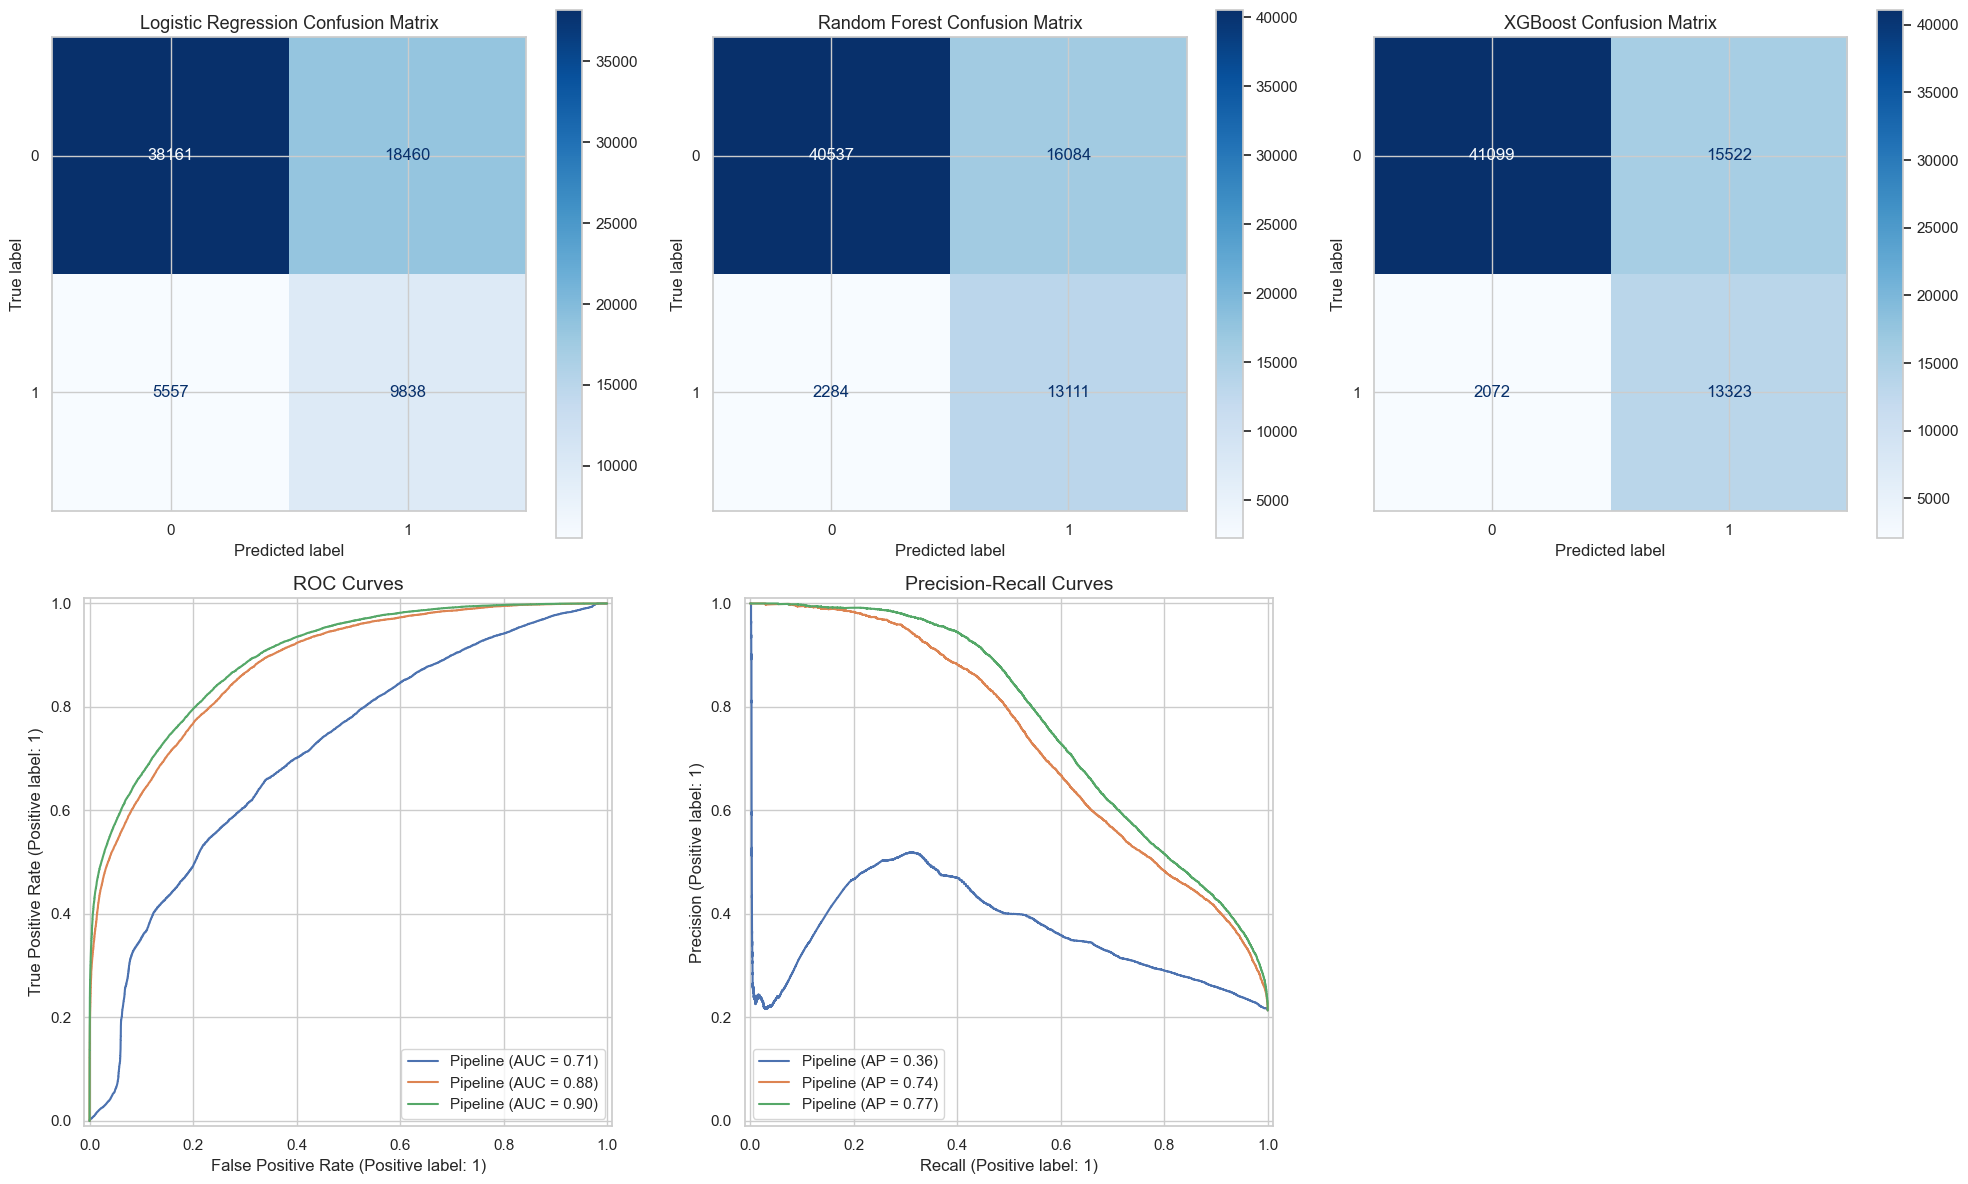


--- Performance Comparison Table ---
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC  PR-AUC
Model                                                                      
Logistic Regression    0.6665     0.3477  0.6390    0.4503   0.7090  0.3644
Random Forest          0.7449     0.4491  0.8516    0.5881   0.8803  0.7373
XGBoost                0.7557     0.4619  0.8654    0.6023   0.8954  0.7707

Best Balanced Model Selected: XGBoost (F1-Score: 0.6023, Recall: 0.8654)


In [13]:
models_dict = {
    'Logistic Regression': best_lr,
    'Random Forest': best_rf,
    'XGBoost': best_xgb
}

metrics_results = []

# Plotting curves
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for idx, (name, model) in enumerate(models_dict.items()):
    # Predictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Calculate Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)

    metrics_results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc
    })

    # Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm).plot(ax=axes[idx], cmap='Blues', values_format='d')
    axes[idx].set_title(f'{name} Confusion Matrix', fontsize=13)

# Plot ROC Curve
for name, model in models_dict.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=axes[3])
axes[3].set_title('ROC Curves', fontsize=14)

# Plot PR Curve
for name, model in models_dict.items():
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test, ax=axes[4])
axes[4].set_title('Precision-Recall Curves', fontsize=14)

# Clean up empty subplot
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

# Show Comparison Table
comparison_df = pd.DataFrame(metrics_results).set_index('Model')
print('\n--- Performance Comparison Table ---')
print(comparison_df.round(4))

# Automatic balanced model selection based on F1 Score
best_model_name = comparison_df['F1 Score'].idxmax()
best_model = models_dict[best_model_name]
print(f'\nBest Balanced Model Selected: {best_model_name} '
      f'(F1-Score: {comparison_df.loc[best_model_name, "F1 Score"]:.4f}, '
      f'Recall: {comparison_df.loc[best_model_name, "Recall"]:.4f})')


## 11. Model Explainability (SHAP)

Implement SHAP explainability for the selected best model to analyze global feature importances (summary plot and bar plot) and build a local explanation function `explain_prediction()` that visualizes the force contribution waterfall chart for suspicious predictions.

**Note**: We transform the test/train data using the fitted preprocessor before computing SHAP values.


Initializing SHAP explainer for selected model: XGBoost...


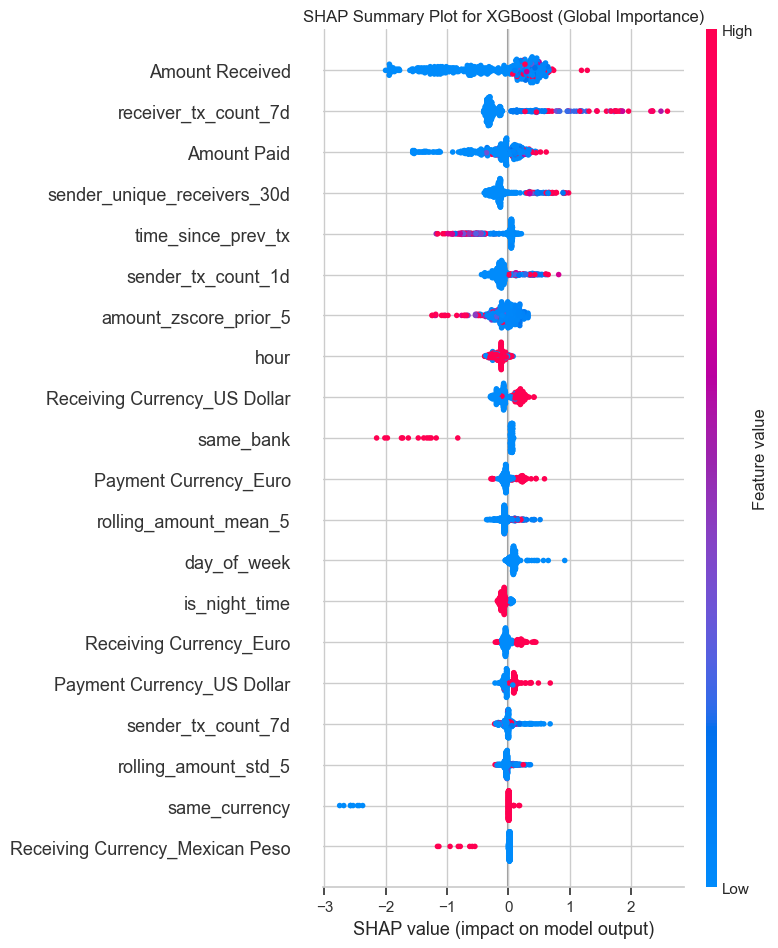

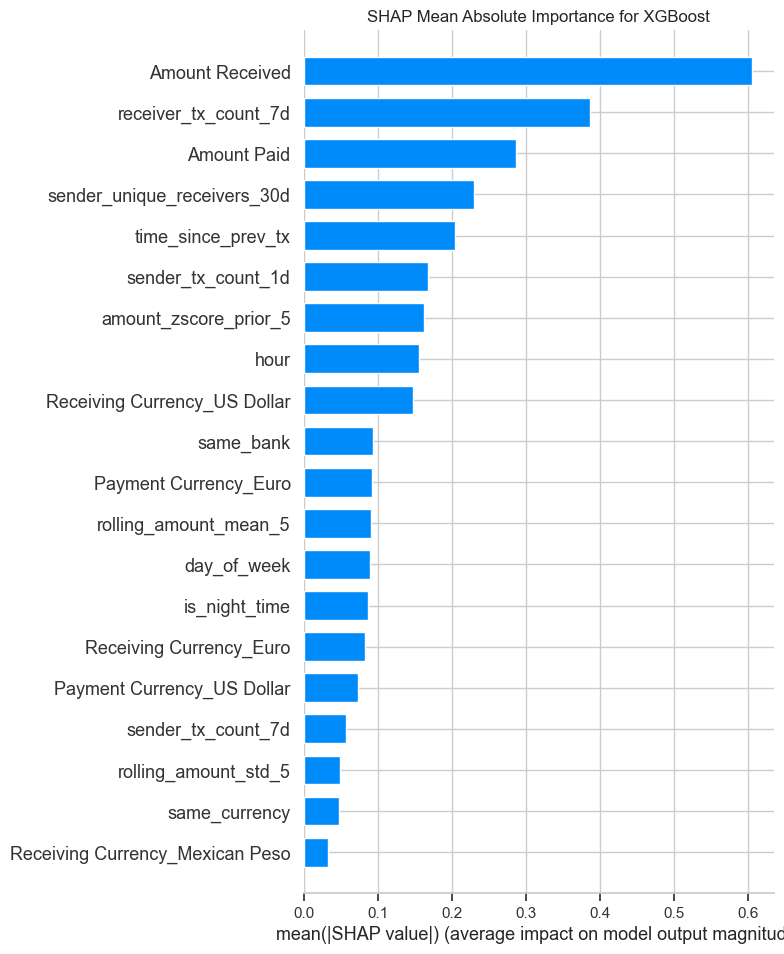

In [14]:
def extract_pos_class_shap(sv, is_single_sample=False):
    """Extract SHAP values for the positive class from different SHAP output formats."""
    if isinstance(sv, list):
        if is_single_sample:
            return sv[1][0]
        else:
            return sv[1]
    elif isinstance(sv, np.ndarray):
        if sv.ndim == 3:
            if sv.shape[-1] == 2:
                return sv[0, :, 1] if is_single_sample else sv[:, :, 1]
            elif sv.shape[0] == 2:
                return sv[1, 0, :] if is_single_sample else sv[1, :, :]
        elif sv.ndim == 2:
            return sv[0] if is_single_sample else sv
    return sv


print(f'Initializing SHAP explainer for selected model: {best_model_name}...')
final_clf = best_model.named_steps['classifier']
selected_preprocessor = best_model.named_steps['preprocessor']

# Transform data using the fitted preprocessor from the selected pipeline
X_train_processed = selected_preprocessor.transform(X_train)
X_test_processed = selected_preprocessor.transform(X_test)

# Select a representative sample of test set to compute SHAP values quickly
X_test_sub = X_test_processed[:500]

# TreeExplainer for XGBoost/RF, LinearExplainer for Logistic Regression
if 'Logistic Regression' in best_model_name:
    explainer = shap.LinearExplainer(final_clf, X_train_processed[:100])
    shap_values = explainer.shap_values(X_test_sub)
else:
    explainer = shap.TreeExplainer(final_clf, feature_perturbation='tree_path_dependent')
    shap_values = explainer.shap_values(X_test_sub)

# Extract correct SHAP arrays for binary classification
shap_values_pos = extract_pos_class_shap(shap_values, is_single_sample=False)

# Global summary plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_pos, X_test_sub, feature_names=feature_names, show=False)
plt.title(f'SHAP Summary Plot for {best_model_name} (Global Importance)')
plt.show()

# Global bar plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_pos, X_test_sub, plot_type='bar', feature_names=feature_names, show=False)
plt.title(f'SHAP Mean Absolute Importance for {best_model_name}')
plt.show()



--- Local Waterfall Plot for Prediction: FRAUD (Risk Probability: 0.6678) ---


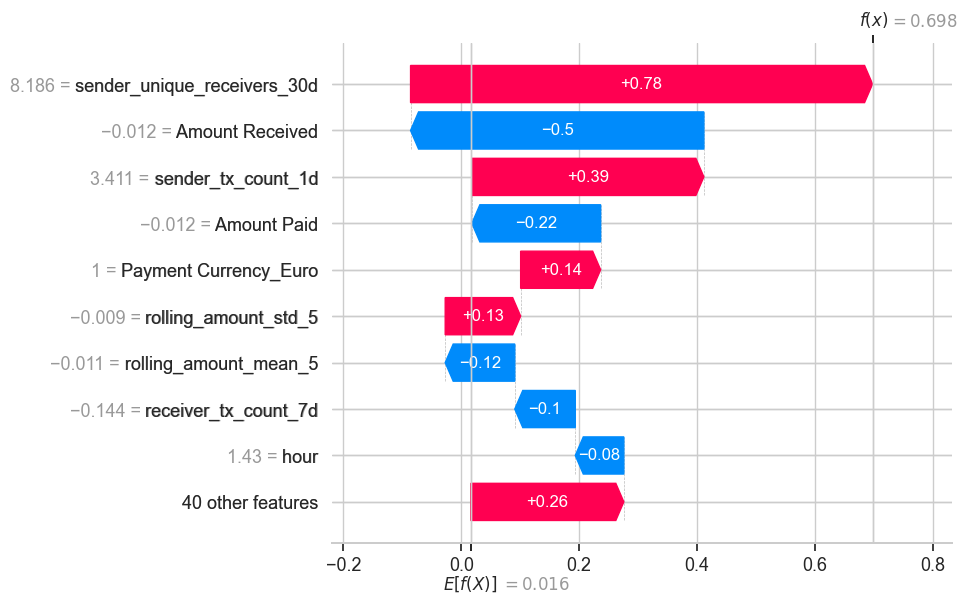

Sample explanation output: {'prediction': 1, 'probability': 0.6677917838096619, 'top_contributing_features': [{'feature': 'sender_unique_receivers_30d', 'shap_value': 0.7842471599578857}, {'feature': 'Amount Received', 'shap_value': -0.4978901147842407}, {'feature': 'sender_tx_count_1d', 'shap_value': 0.393818736076355}, {'feature': 'Amount Paid', 'shap_value': -0.21858321130275726}, {'feature': 'Payment Currency_Euro', 'shap_value': 0.13578657805919647}, {'feature': 'rolling_amount_std_5', 'shap_value': 0.12808246910572052}, {'feature': 'rolling_amount_mean_5', 'shap_value': -0.1181165874004364}, {'feature': 'receiver_tx_count_7d', 'shap_value': -0.10270892828702927}, {'feature': 'hour', 'shap_value': -0.08240104466676712}, {'feature': 'Receiving Currency_Euro', 'shap_value': 0.07756826281547546}]}


In [15]:
def explain_prediction(sample_df, top_n=10):
    """
    Explain a single transaction prediction using SHAP.

    Parameters
    ----------
    sample_df : pd.DataFrame
        Single-row DataFrame with the transaction features.
    top_n : int
        Number of top contributing features to return.

    Returns
    -------
    dict with prediction, probability, and top contributing features.
    """
    # Ensure correct feature alignment
    sample_df = sample_df[X_train.columns]
    processed = selected_preprocessor.transform(sample_df)

    pred = best_model.predict(sample_df)[0]
    prob = best_model.predict_proba(sample_df)[:, 1][0]

    # Calculate local SHAP
    local_val = explainer.shap_values(processed)
    local_val = extract_pos_class_shap(local_val, is_single_sample=True)

    feat_shaps = list(zip(feature_names, local_val))
    sorted_feats = sorted(feat_shaps, key=lambda x: abs(x[1]), reverse=True)

    # Plot Local Waterfall
    print(f'\n--- Local Waterfall Plot for Prediction: {"FRAUD" if pred==1 else "LEGITIMATE"} '
          f'(Risk Probability: {prob:.4f}) ---')
    expected_val = explainer.expected_value
    if isinstance(expected_val, (list, np.ndarray)):
        expected_val = expected_val[1]  # Positive class
    shap.waterfall_plot(shap.Explanation(
        values=local_val,
        base_values=expected_val,
        data=processed[0],
        feature_names=feature_names
    ))
    plt.show()

    return {
        'prediction': int(pred),
        'probability': float(prob),
        'top_contributing_features': [
            {'feature': name, 'shap_value': float(val)} for name, val in sorted_feats[:top_n]
        ]
    }


# Test local explainer with a laundering sample (target == 1)
fraud_indices = np.where(y_test == 1)[0]
if len(fraud_indices) > 0:
    test_idx = fraud_indices[0]
    sample_tx = X_test.iloc[[test_idx]]
    explanation = explain_prediction(sample_tx)
    print('Sample explanation output:', explanation)
else:
    print('No laundering cases found in test set to display waterfall.')


## 12. Save Artifacts

Save the preprocessing pipeline, all three trained models (to support deployment comparisons), feature names, and target encoder to the `models/` directory.


In [16]:
os.makedirs('models', exist_ok=True)

# Save all three models
joblib.dump(best_lr, 'models/logistic_regression_model.joblib')
joblib.dump(best_rf, 'models/random_forest_model.joblib')
joblib.dump(best_xgb, 'models/xgboost_model.joblib')
print('Saved model joblib files.')

# Save feature names
with open('models/feature_names.json', 'w') as f:
    json.dump(feature_names, f)
print('Saved feature_names.json')

# Save Label Encoder (since class target is 0/1 binary, we construct a binary LabelEncoder)
le = LabelEncoder()
le.fit([0, 1])
joblib.dump(le, 'models/label_encoder.joblib')
print('Saved label_encoder.joblib')

# Verify Pipeline
print('\n--- Pipeline Verification ---')
model = joblib.load("models/xgboost_model.joblib")
print(type(model))
print(model.named_steps.keys())


Saved model joblib files.
Saved feature_names.json
Saved label_encoder.joblib

--- Pipeline Verification ---
<class 'sklearn.pipeline.Pipeline'>
dict_keys(['preprocessor', 'classifier'])


## 13. Reusable Inference Function

The `predict_transaction()` function downcasts inputs, performs appropriate feature engineering, runs model preprocessing, and outputs predictions, risk probabilities, and explanations. It supports model selection between logistic_regression, random_forest, and xgboost.


In [17]:
def predict_transaction(transaction_df, model_name='xgboost'):
    """
    Run end-to-end inference on a batch or single row transaction.

    Parameters
    ----------
    transaction_df : pd.DataFrame
        Input transaction data with required columns.
    model_name : str
        One of 'logistic_regression', 'random_forest', 'xgboost'.

    Returns
    -------
    dict or list of dicts with prediction, probability, risk_score, and top_features.
    """
    # Create a copy
    df_inf = transaction_df.copy()

    # Parse dates vectorially if string
    if 'Timestamp' in df_inf.columns and not pd.api.types.is_datetime64_any_dtype(df_inf['Timestamp']):
        df_inf['Timestamp'] = pd.to_datetime(df_inf['Timestamp'], errors='coerce', format='%Y/%m/%d %H:%M')

    # Feature engineering fallback/mapping
    required_cols = [
        'time_since_prev_tx', 'sender_tx_count_1d', 'sender_tx_count_7d', 'receiver_tx_count_7d',
        'rolling_amount_mean_5', 'rolling_amount_std_5', 'sender_unique_receivers_30d', 'amount_zscore_prior_5',
        'same_currency', 'same_bank', 'is_round_amount', 'hour', 'day_of_week', 'is_weekend',
        'is_night_time', 'high_value_trans', 'amount_diff'
    ]

    # Vector calculations for columns that do not require state lookup
    if 'Amount Received' in df_inf.columns and 'Amount Paid' in df_inf.columns:
        df_inf['is_round_amount'] = ((df_inf['Amount Received'] % 1 == 0) & (df_inf['Amount Paid'] % 1 == 0)).astype(int)
        df_inf['amount_diff'] = np.abs(df_inf['Amount Received'] - df_inf['Amount Paid'])
        df_inf['high_value_trans'] = (df_inf['Amount Paid'] > 50000).astype(int)

    if 'Receiving Currency' in df_inf.columns and 'Payment Currency' in df_inf.columns:
        df_inf['same_currency'] = (df_inf['Receiving Currency'] == df_inf['Payment Currency']).astype(int)
    if 'From Bank' in df_inf.columns and 'To Bank' in df_inf.columns:
        df_inf['same_bank'] = (df_inf['From Bank'] == df_inf['To Bank']).astype(int)

    if 'Timestamp' in df_inf.columns:
        df_inf['hour'] = df_inf['Timestamp'].dt.hour
        df_inf['day_of_week'] = df_inf['Timestamp'].dt.dayofweek
        df_inf['is_weekend'] = df_inf['day_of_week'].isin([5, 6]).astype(int)
        df_inf['is_night_time'] = ((df_inf['hour'] >= 22) | (df_inf['hour'] <= 6)).astype(int)

    # State calculations (velocity/rolling) if context exists, otherwise populate default
    for c in required_cols:
        if c not in df_inf.columns:
            if c == 'time_since_prev_tx':
                df_inf[c] = -1.0
            elif c == 'amount_zscore_prior_5':
                df_inf[c] = 0.0
            elif 'rolling' in c or 'mean' in c:
                df_inf[c] = df_inf['Amount Paid'] if 'Amount Paid' in df_inf.columns else 0.0
            else:
                df_inf[c] = 0.0

    # Select the model file
    model_mapping = {
        'logistic_regression': 'models/logistic_regression_model.joblib',
        'random_forest': 'models/random_forest_model.joblib',
        'xgboost': 'models/xgboost_model.joblib'
    }

    path = model_mapping.get(model_name.lower())
    if not path:
        raise ValueError(f"Model name '{model_name}' not recognized. Choose from: {list(model_mapping.keys())}")

    clf_pipeline = joblib.load(path)

    # Ensure correct columns before preprocessing
    X_inf = df_inf[X_train.columns]

    preds = clf_pipeline.predict(X_inf)
    probs = clf_pipeline.predict_proba(X_inf)[:, 1]

    # Load preprocessor to output contributions
    prep = clf_pipeline.named_steps['preprocessor']
    with open('models/feature_names.json', 'r') as f:
        feats = json.load(f)

    processed_inf = prep.transform(X_inf)

    results = []
    for j in range(len(df_inf)):
        pred = int(preds[j])
        prob = float(probs[j])
        risk_score = round(prob * 100, 2)

        # Sort contributing feature locations based on scale of deviation from zero
        contributions = []
        for f_idx, f_name in enumerate(feats):
            val = float(processed_inf[j, f_idx])
            if abs(val) > 0.1:
                contributions.append({'feature': f_name, 'scaled_value': val})

        sorted_contribs = sorted(contributions, key=lambda x: abs(x['scaled_value']), reverse=True)

        results.append({
            'prediction': pred,
            'probability': prob,
            'risk_score': risk_score,
            'top_features': [c['feature'] for c in sorted_contribs[:5]]
        })

    return results if len(results) > 1 else results[0]


In [18]:
# Verify inference function with dummy data
dummy_tx = pd.DataFrame([{
    'Timestamp': '2022/09/25 15:30',
    'From Bank': 1200, 'Account': 'A1', 'To Bank': 1300, 'Account.1': 'A2',
    'Amount Received': 25000.0, 'Receiving Currency': 'US Dollar',
    'Amount Paid': 25000.0, 'Payment Currency': 'US Dollar',
    'Payment Format': 'Wire', 'Bank Name_sender': 'SenderBank',
    'Entity ID_sender': 'E_Send', 'Entity Name_sender': 'SenderEntity',
    'Bank Name_receiver': 'RecBank', 'Entity ID_receiver': 'E_Rec',
    'Entity Name_receiver': 'RecEntity',
    'Source_Set': 'HI-Medium'
}])

print('\n--- Verification Inference (XGBoost) ---')
print(predict_transaction(dummy_tx, 'xgboost'))
print('\n--- Verification Inference (Random Forest) ---')
print(predict_transaction(dummy_tx, 'random_forest'))



--- Verification Inference (XGBoost) ---


{'prediction': 1, 'probability': 0.8326607942581177, 'risk_score': 83.27, 'top_features': ['is_round_amount', 'is_weekend', 'day_of_week', 'Receiving Currency_US Dollar', 'Payment Currency_US Dollar']}

--- Verification Inference (Random Forest) ---


{'prediction': 1, 'probability': 0.5926560911164513, 'risk_score': 59.27, 'top_features': ['is_round_amount', 'is_weekend', 'day_of_week', 'Receiving Currency_US Dollar', 'Payment Currency_US Dollar']}


## 14. Summary & Recommendations

This section summarizes the performance of all three trained models and provides clear, actionable recommendations for integration into an AML Investigation Agent.


In [19]:
print('--- AML FRAUD DETECTION PIPELINE SUMMARY ---\n')
print(f'Best Performing Balanced Model: {best_model_name}')

print('\nMetrics comparison:')
print(comparison_df.round(4))

print('\nSaved Artifact Locations:')
print('- Logistic Regression model: models/logistic_regression_model.joblib')
print('- Random Forest model:       models/random_forest_model.joblib')
print('- XGBoost model:             models/xgboost_model.joblib')
print('- Feature names JSON:        models/feature_names.json')
print('- Target label encoder:      models/label_encoder.joblib')

print('\nTop 20 most important features (SHAP global importance):')
mean_abs_shaps = np.abs(shap_values_pos).mean(axis=0)
global_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': mean_abs_shaps
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)
print(global_importance.head(20))

print('\n--- Recommendations for Deployment into an AML Investigation Agent ---')
print('1. **Model API Endpoint**: Expose `predict_transaction` via FastAPI to offer millisecond-level transaction screening API endpoints.')
print('2. **State Store Integration**: Integrate Redis or DynamoDB as a fast lookup cache for sender/receiver timestamps and amount history so features like `time_since_prev_tx` and `rolling_average_amount` can be calculated on-the-fly for live payments.')
print('3. **Suspicious Transaction Explanation**: Feed the top contributing features and SHAP values from `explain_prediction` directly into a Large Language Model (LLM) prompt to auto-generate human-readable SAR (Suspicious Activity Report) narratives for compliance officers.')
print('4. **Class Probabilities as Risk Scores**: Use the raw model probability (e.g., probability * 100) as the risk score. Establish alert queues based on threshold levels: Low (< 30), Medium (30-70), and High (> 70) to optimize investigations.')
print('5. **Data Drift & Recalibration**: Monitor feature drift on transactional amounts and velocity, scheduling automatic weekly or monthly pipeline retraining runs to adapt to changing laundering strategies.')


--- AML FRAUD DETECTION PIPELINE SUMMARY ---

Best Performing Balanced Model: XGBoost

Metrics comparison:
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC  PR-AUC
Model                                                                      
Logistic Regression    0.6665     0.3477  0.6390    0.4503   0.7090  0.3644
Random Forest          0.7449     0.4491  0.8516    0.5881   0.8803  0.7373
XGBoost                0.7557     0.4619  0.8654    0.6023   0.8954  0.7707

Saved Artifact Locations:
- Logistic Regression model: models/logistic_regression_model.joblib
- Random Forest model:       models/random_forest_model.joblib
- XGBoost model:             models/xgboost_model.joblib
- Feature names JSON:        models/feature_names.json
- Target label encoder:      models/label_encoder.joblib

Top 20 most important features (SHAP global importance):
                            Feature  Importance
0                   Amount Received    0.604698
1              receiver_tx_coun